# Study · What the record is made of, and what imputation can do about it

This study consumes the unified dataset built by `build_unified_dataset.py`
and never reads the raw archive. It asks one question in four parts:

1. **What is actually there** — per station, per era, per channel: how much
   record exists, when, and how complete it is.
2. **What is missing, and why** — the anatomy of the gaps, their length, their
   season, and the mechanism that produced them. The mechanism decides what is
   reconstructible; the length decides by what.
3. **What can be filled, by what method, to what accuracy** — six fillers
   measured against gaps of known length, each carrying a distribution-free
   interval rather than a point estimate alone.
4. **How long a continuous stretch that buys** — the trade between record
   length gained and data invented, and the recommendation that follows.

## The three findings that shape everything below

**Every channel fails at once.** The missingness is not random and not
conditional on an observed covariate: when the inclinometer is missing, the
air temperature, the humidity and the battery are missing too, on essentially
every gap. That is outage-driven missingness in its purest form, and it has a
hard consequence — *no covariate-conditioned method can ever fill a real gap
in this record*, because the covariates are gone with it.

**The benchmark cannot see that.** An injected gap has its drivers intact, so
a driver-based filler scores well on the benchmark and would fail completely
in production. The study measures it anyway and reports the discrepancy,
because the discrepancy is the point.

**The two eras are two instruments.** Any stretch crossing 2025-02-21 rests on
an estimated offset, and the diurnal-amplitude ratio at the changeover says
how much that estimate can be trusted.

## Imports and configuration

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../../..'))

import ud_lib as ud

pd.set_option('display.width', 170)
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 80)

### Parameters

| Parameter | Purpose |
|---|---|
| `DATA_DIR` | Where `build_unified_dataset.py` wrote its output. |
| `TARGET` | Column the imputation work operates on. |
| `GAP_LENGTHS` | Gap lengths the fillers are benchmarked against, in hours. |
| `N_TRIALS` | Injection sites per gap length. |
| `TOLERANCES` | Accepted mean absolute errors, each generating one policy. |
| `CONFORMAL_LEVEL` | Nominal coverage of the calibrated interval. |

In [2]:
DATA_DIR = '../../../data/interim/unified'
OUTPUT_DIR = 'outputs'
STATION = ud.TARGET_STATION
STATIONS = ud.STATIONS

TARGET = 'inc_comp_joined'     # the continuous-across-eras compensated series
TARGET_PER_ERA = 'inc_comp'    # the per-era-anchored one, for era-local work
DRIVERS = ['tair', 'rh']

GAP_LENGTHS = (1, 3, 6, 12, 24, 48, 72, 168, 336, 720, 1080)
N_TRIALS = 30
FAST_METHODS = ('interpolate', 'seasonal_naive', 'kalman', 'harmonic',
                'drivers')
TOLERANCES = (2.0, 5.0, 10.0, 15.0, 20.0, 40.0)
CONFORMAL_LEVEL = 0.90

SAMPLING_HOURS = 1.0

os.makedirs(OUTPUT_DIR, exist_ok=True)
ud.set_context('notebook')

'notebook'

## Step 1 · Read the unified dataset

In [3]:
frames = {s: ud.load_unified(DATA_DIR, s) for s in STATIONS}
df = frames[STATION]

print(f'{STATION}: {len(df)} hourly slots, '
      f'{df.index.min()} to {df.index.max()}')
print(f'columns: {list(df.columns)}')
for col in (TARGET_PER_ERA, TARGET):
    print(f'  {col:18s} observed {df[col].notna().sum():6d} '
          f'({100 * df[col].notna().mean():.1f} %)')

st02: 70561 hourly slots, 2018-07-26 00:00:00 to 2026-08-13 00:00:00
columns: ['batt', 'tair', 'rh', 'inc', 'sr', 'twall', 'era', 'instrument', 'inc_comp', 'inc_source', 'station', 'inc_comp_joined']
  inc_comp           observed  49463 (70.1 %)
  inc_comp_joined    observed  49463 (70.1 %)


/Users/eugenio/Library/CloudStorage/GoogleDrive-eugeniomoreira@iaud.ufc.br/My Drive/_UNIPG/neuralprophet-shm/neuralprophet-shm/studies/unified_dataset/ud_lib.py:640: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path, index_col=0, parse_dates=True)
/Users/eugenio/Library/CloudStorage/GoogleDrive-eugeniomoreira@iaud.ufc.br/My Drive/_UNIPG/neuralprophet-shm/neuralprophet-shm/studies/unified_dataset/ud_lib.py:640: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path, index_col=0, parse_dates=True)


## Step 2 · What is actually there

### Per station

In [4]:
classification = ud.classify_stations(frames, freq=ud.ANALYSIS_FREQ)
display(classification[['eras', 'first_reading', 'last_reading', 'span_days',
                        'observed_days', 'coverage_of_span_%',
                        'coverage_of_archive_%']])
classification.to_csv(f'{OUTPUT_DIR}/U_04_classification.csv')

,eras,first_reading,last_reading,span_days,observed_days,coverage_of_span_%,coverage_of_archive_%
station,,,,,,,
st01,legacy,2018-07-26 00:00:00,2022-06-01 07:00:00,1406.3,1118.7,79.5,38.0
st02,legacy+current,2018-07-26 00:00:00,2026-08-13 00:00:00,2940.0,2061.0,70.1,70.1
st03,legacy,2018-07-26 00:00:00,2023-06-24 15:00:00,1794.6,984.1,54.8,33.5


**The network did not survive to the changeover.** Two of the three legacy
stations stopped recording long before the February 2025 replacement, so the
archive narrows from three instrumented locations to one in stages rather
than at a single moment.

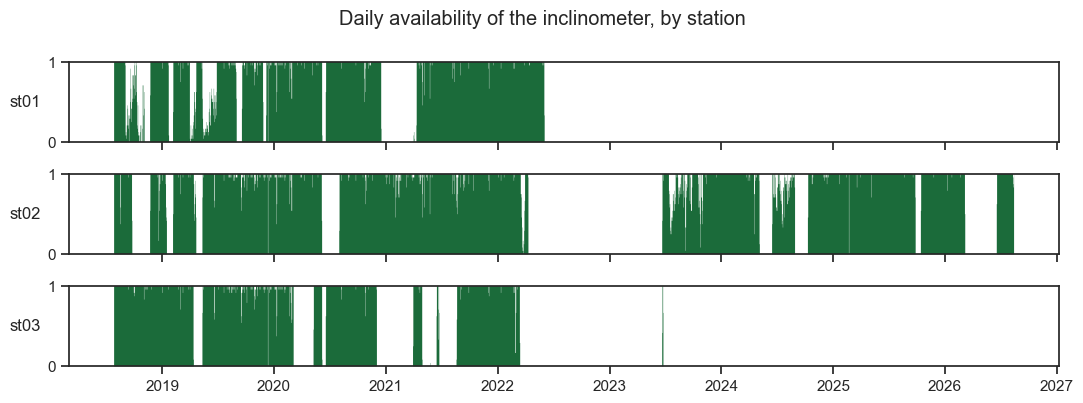

In [5]:
ud.plot_station_completeness(
    frames, column='inc',
    title='Daily availability of the inclinometer, by station',
    save_path=OUTPUT_DIR, filename=f'U_F03_station_completeness')
plt.show()

### Per era, for the target station

In [6]:
era_table = ud.era_profile(df, freq=ud.ANALYSIS_FREQ)
display(era_table)
era_table.to_csv(f'{OUTPUT_DIR}/U_05_era_profile_{STATION}.csv')

,from,to,slots,span_days,annual_cycles,batt_%,tair_%,rh_%,inc_%,sr_%,twall_%,inc_mean,inc_sd
era,,,,,,,,,,,,,
legacy,2018-07-26,2025-02-20,57625,2401.0,6.57,68.5,68.5,68.5,68.5,0.0,0.0,-304.34,41.37
current,2025-02-21,2026-08-13,12913,538.0,1.47,77.2,77.2,77.2,77.2,69.1,36.8,-319.15,50.49


### Per channel, along the record

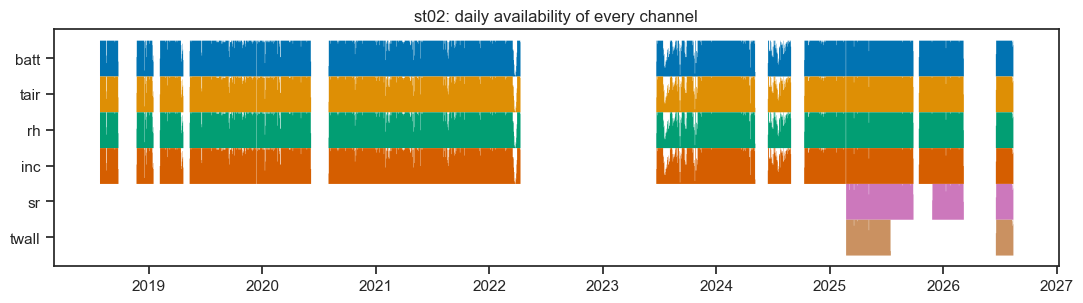

In [7]:
availability = ud.channel_availability(df)
ud.plot_channel_availability(
    availability,
    title=f'{STATION}: daily availability of every channel',
    save_path=OUTPUT_DIR, filename=f'U_F04_channel_availability')
plt.show()

monthly = ud.monthly_completeness(frames, column='inc')
monthly.to_csv(f'{OUTPUT_DIR}/U_06_monthly_completeness.csv')

### The calendar view

Completeness as a year-by-day-of-year map, which is where a seasonal pattern
in the outages would show itself.

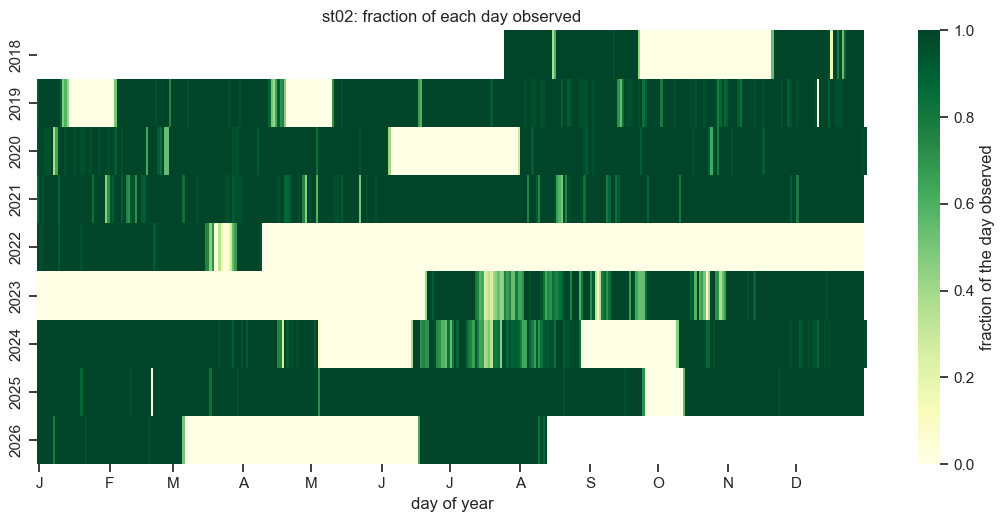

In [8]:
calendar = ud.completeness_calendar(df[TARGET_PER_ERA])
ud.plot_completeness_calendar(
    calendar,
    title=f'{STATION}: fraction of each day observed',
    save_path=OUTPUT_DIR, filename=f'U_F05_calendar')
plt.show()
calendar.round(3).to_csv(f'{OUTPUT_DIR}/U_07_completeness_calendar.csv')

## Step 3 · What is missing, and why

### Every gap, individually

In [9]:
gaps = ud.gap_table(df[TARGET_PER_ERA], dt_hours=SAMPLING_HOURS)
bands = ud.gap_bands(gaps)
display(bands)
gaps.to_csv(f'{OUTPUT_DIR}/U_08_gap_table.csv', index=False)
bands.to_csv(f'{OUTPUT_DIR}/U_09_gap_bands.csv')

print(f'{len(gaps)} gaps in all; the longest is '
      f'{gaps["hours"].max():.0f} h ({gaps["hours"].max() / 24:.0f} days)')

,n_gaps,hours_lost,share_of_missing_%,median_h
band,,,,
<= 3 h,426,619.0,2.9,1.0
3-6 h,60,284.0,1.3,4.0
6-24 h,72,906.0,4.3,11.0
1-3 d,2,65.0,0.3,32.5
3-7 d,0,0.0,0.0,NaN
7-30 d,3,1415.0,6.7,491.0
> 30 d,6,17809.0,84.4,1396.0


569 gaps in all; the longest is 10503 h (438 days)


### The gaps that dominate

In [10]:
big = gaps[gaps['days'] > 3].copy()
display(big[['start', 'end', 'days', 'season', 'context_before_h',
             'context_after_h']].reset_index(drop=True))
big.to_csv(f'{OUTPUT_DIR}/U_10_major_gaps.csv', index=False)

print(f'{len(big)} gaps longer than three days hold '
      f'{100 * big["hours"].sum() / gaps["hours"].sum():.1f} % of all missing '
      f'hours.')

,start,end,days,season,context_before_h,context_after_h
0,2022-04-09 23:00:00,2023-06-21 13:00:00,437.62,MAM,266.0,62.0
1,2026-03-06 12:00:00,2026-06-18 08:00:00,103.88,MAM,358.0,1272.0
2,2018-09-23 10:00:00,2018-11-21 10:00:00,59.04,SON,264.0,612.0
3,2020-06-04 10:00:00,2020-07-31 16:00:00,57.29,JJA,299.0,144.0
4,2024-08-27 20:00:00,2024-10-09 12:00:00,42.71,JJA,74.0,320.0
5,2024-05-04 03:00:00,2024-06-14 14:00:00,41.50,MAM,48.0,92.0
6,2019-01-14 18:00:00,2019-02-04 11:00:00,20.75,DJF,8.0,443.0
7,2019-04-20 20:00:00,2019-05-11 06:00:00,20.46,MAM,11.0,104.0
8,2025-09-25 17:00:00,2025-10-13 10:00:00,17.75,SON,195.0,1011.0


9 gaps longer than three days hold 91.1 % of all missing hours.


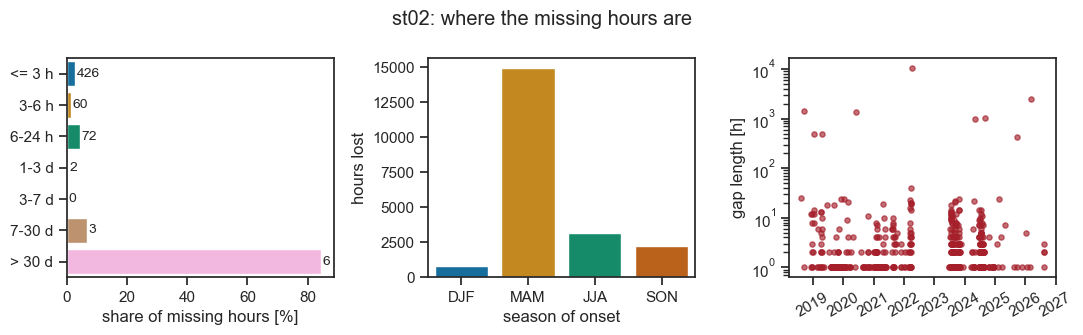

In [11]:
ud.plot_gap_anatomy(
    gaps, bands=bands,
    title=f'{STATION}: where the missing hours are',
    save_path=OUTPUT_DIR, filename=f'U_F06_gap_anatomy')
plt.show()

### Why they are missing

The taxonomy is a design input, not a label. A gap missing at random can be
filled from its neighbours; a gap whose absence tracks an observed covariate
can be filled from that covariate; a gap that is an outage takes the
covariates with it and can be filled from neither.

In [12]:
mechanism = ud.missingness_mechanism(df, target='inc')
display(mechanism)
mechanism.to_csv(f'{OUTPUT_DIR}/U_11_missingness_mechanism.csv')

print(f'Missing: {mechanism.attrs["missing_hours"]:.0f} h '
      f'({mechanism.attrs["missing_%"]:.1f} % of the archive span)')

,joint_missing_%,r,p,testable_rows,reading
covariate,,,,,
batt,100.0,NaN,NaN,0,"always missing together — outage (MNAR), unusa..."
tair,100.0,NaN,NaN,0,"always missing together — outage (MNAR), unusa..."
rh,100.0,NaN,NaN,0,"always missing together — outage (MNAR), unusa..."
sr,100.0,NaN,NaN,0,"always missing together — outage (MNAR), unusa..."
twall,100.0,NaN,NaN,0,"always missing together — outage (MNAR), unusa..."


Missing: 21098 h (29.9 % of the archive span)


The current era is tested separately, because solar radiation and wall
temperature do not exist before 2025-02-21 and would otherwise be counted as
missing for seven years.

In [13]:
current = df.loc[df['era'] == 'current']
mechanism_current = ud.missingness_mechanism(current, target='inc')
display(mechanism_current)
mechanism_current.to_csv(f'{OUTPUT_DIR}/U_12_missingness_current.csv')

,joint_missing_%,r,p,testable_rows,reading
covariate,,,,,
batt,100.0,NaN,NaN,0,"always missing together — outage (MNAR), unusa..."
tair,100.0,NaN,NaN,0,"always missing together — outage (MNAR), unusa..."
rh,100.0,NaN,NaN,0,"always missing together — outage (MNAR), unusa..."
sr,100.0,NaN,NaN,0,"always missing together — outage (MNAR), unusa..."
twall,100.0,NaN,NaN,0,"always missing together — outage (MNAR), unusa..."


## Step 4 · What can be filled, and how well

Six fillers of increasing ambition, measured against gaps of known length
injected where the record is complete. No filler sees the values it is asked
to reproduce.

The range matters because no single method is right at every length:
interpolation is unbeatable across an hour and meaningless across a month,
while a seasonal model knows nothing useful about an hour and is most of what
is left after a week.

In [14]:
bench = ud.benchmark_fillers(
    df, TARGET_PER_ERA, gap_lengths=GAP_LENGTHS, methods=FAST_METHODS,
    drivers=DRIVERS, n_trials=N_TRIALS, seed=0,
    min_context_hours=48, dt_hours=SAMPLING_HOURS)

display(bench.pivot(index='gap_hours', columns='method', values='MAE_mdeg'))
bench.to_csv(f'{OUTPUT_DIR}/U_13_filler_benchmark.csv', index=False)

signal_sd = float(df[TARGET_PER_ERA].std())
print(f'For scale, the signal standard deviation is {signal_sd:.1f} mdeg.')

method,drivers,harmonic,interpolate,kalman,seasonal_naive
gap_hours,,,,,
1.0,1.8309,3.8404,1.2157,1.0447,4.5810
3.0,1.1412,3.7277,1.6112,1.7472,5.6664
6.0,2.4809,3.9987,2.7880,2.9883,4.5247
12.0,7.2489,9.9840,8.7468,8.5506,9.0359
24.0,4.0049,6.1323,9.8331,5.7090,5.1199
48.0,2.0710,4.7959,9.5353,4.1796,4.9436
72.0,5.5049,8.2383,14.7003,7.3063,7.3101
168.0,6.9786,10.0218,10.6759,9.8642,8.0463
336.0,8.7795,12.8402,21.7888,13.0730,11.5026


For scale, the signal standard deviation is 80.9 mdeg.


### The uncertainty that goes with a filled value

A mean absolute error says how wrong a filler is on average. It does not say
how wrong a particular filled value might be, and that is what a downstream
consumer needs in order to weight or exclude it. The per-trial errors are
therefore treated as a calibration sample and converted directly into an
interval, with no distributional assumption — these errors are neither
Gaussian nor independent, and assuming either would understate them.

In [15]:
conformal = ud.conformal_bands(bench, level=CONFORMAL_LEVEL)
display(conformal.pivot(index='gap_hours', columns='method',
                        values='half_width_mdeg'))
conformal.to_csv(f'{OUTPUT_DIR}/U_14_conformal_bands.csv', index=False)

method,drivers,harmonic,interpolate,kalman,seasonal_naive
gap_hours,,,,,
1.0,3.7937,7.6261,3.1621,2.0583,8.3917
3.0,2.7965,6.4892,3.4581,4.1083,10.2583
6.0,3.7049,8.9532,6.1989,5.8109,10.1667
12.0,10.7195,20.9827,15.4255,14.9425,14.9900
24.0,4.0468,9.0027,22.7121,8.5078,9.5575
48.0,4.3303,11.2380,24.9803,9.1478,10.9700
72.0,7.9068,14.5728,21.1511,11.0082,12.3017
168.0,6.8371,14.9541,21.1923,15.7496,13.9167
336.0,11.1870,20.4220,32.4447,21.2699,18.4008


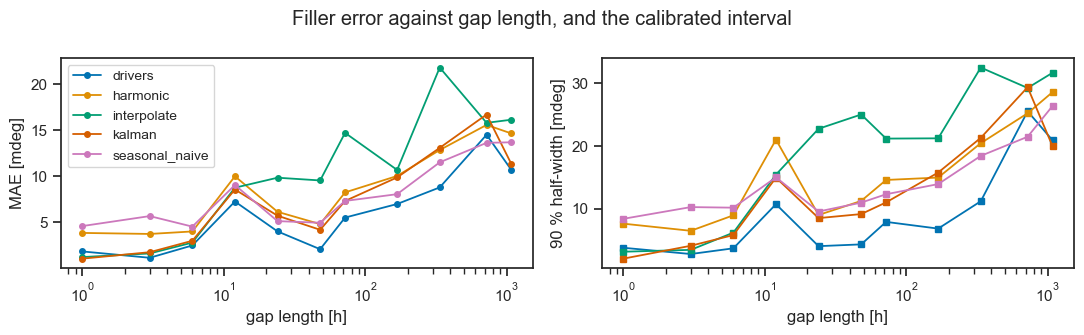

In [16]:
ud.plot_filler_benchmark(
    bench, conformal=conformal,
    title='Filler error against gap length, and the calibrated interval',
    save_path=OUTPUT_DIR, filename=f'U_F07_filler_benchmark')
plt.show()

### The driver filler, and why its score is not to be believed

The benchmark injects gaps where the record is complete, so the drivers are
present throughout every injected gap. Step 3 established that in a *real*
gap they are not: every channel fails together. The driver filler is
therefore being scored under conditions that never occur in production.

This is the exchangeability assumption behind any conformal guarantee, stated
concretely and failing.

In [17]:
driver_rows = bench[bench['method'] == 'drivers']
best_other = (bench[bench['method'] != 'drivers']
              .groupby('gap_hours')['MAE_mdeg'].min())
comparison = pd.DataFrame({
    'drivers_MAE': driver_rows.set_index('gap_hours')['MAE_mdeg'],
    'best_other_MAE': best_other,
})
comparison['drivers_advantage_%'] = (
    100 * (comparison['best_other_MAE'] - comparison['drivers_MAE'])
    / comparison['best_other_MAE']).round(1)
comparison['available_in_a_real_gap'] = False
display(comparison)
comparison.to_csv(f'{OUTPUT_DIR}/U_15_driver_illusion.csv')

,drivers_MAE,best_other_MAE,drivers_advantage_%,available_in_a_real_gap
gap_hours,,,,
1.0,1.8309,1.0447,-75.3,False
3.0,1.1412,1.6112,29.2,False
6.0,2.4809,2.7880,11.0,False
12.0,7.2489,8.5506,15.2,False
24.0,4.0049,5.1199,21.8,False
48.0,2.0710,4.1796,50.4,False
72.0,5.5049,7.3063,24.7,False
168.0,6.9786,8.0463,13.3,False
336.0,8.7795,11.5026,23.7,False


## Step 5 · The policies

A policy assigns one filler to each gap-length band, or refuses the band. A
refusal is the useful output, not a failure: it names the holes that have to
stay holes.

**The driver filler is measured and then refused.** It cannot run on a real
gap, so allowing a policy to select it would credit the fill with an accuracy
the fill does not have — in practice it would degrade silently to
interpolation while still being labelled `drivers`. The policy therefore
chooses among the methods that can actually run, and reports what excluding
the best benchmark score costs at each band.

In [18]:
policies = ud.band_policies(bench, TOLERANCES)
policy_frames = []
for label, policy in policies.items():
    entry = policy[['max_gap_h', 'method', 'MAE_mdeg', 'benchmark_best',
                    'benchmark_best_MAE', 'cost_of_availability_mdeg']].copy()
    entry['policy'] = label
    policy_frames.append(entry)
    print(f'\n=== {label} ===')
    display(policy[['max_gap_h', 'method', 'MAE_mdeg', 'benchmark_best',
                    'cost_of_availability_mdeg', 'decision']])

pd.concat(policy_frames).to_csv(f'{OUTPUT_DIR}/U_16_policies.csv')


=== tolerance 2 mdeg ===


,max_gap_h,method,MAE_mdeg,benchmark_best,cost_of_availability_mdeg,decision
band,,,,,,
<= 1 h,1.0,kalman,1.0447,kalman,0.0000,fill with kalman
<= 3 h,3.0,interpolate,1.6112,drivers,0.4700,fill with interpolate
<= 6 h,6.0,none,NaN,drivers,0.3071,leave missing — no available method meets the ...
<= 12 h,12.0,none,NaN,drivers,1.3017,leave missing — no available method meets the ...
<= 24 h,24.0,none,NaN,drivers,1.1150,leave missing — no available method meets the ...
<= 48 h,48.0,none,NaN,drivers,2.1086,leave missing — no available method meets the ...
<= 72 h,72.0,none,NaN,drivers,1.8014,leave missing — no available method meets the ...
<= 168 h,168.0,none,NaN,drivers,1.0677,leave missing — no available method meets the ...
<= 336 h,336.0,none,NaN,drivers,2.7231,leave missing — no available method meets the ...



=== tolerance 5 mdeg ===


,max_gap_h,method,MAE_mdeg,benchmark_best,cost_of_availability_mdeg,decision
band,,,,,,
<= 1 h,1.0,kalman,1.0447,kalman,0.0000,fill with kalman
<= 3 h,3.0,interpolate,1.6112,drivers,0.4700,fill with interpolate
<= 6 h,6.0,interpolate,2.7880,drivers,0.3071,fill with interpolate
<= 12 h,12.0,none,NaN,drivers,1.3017,leave missing — no available method meets the ...
<= 24 h,24.0,none,NaN,drivers,1.1150,leave missing — no available method meets the ...
<= 48 h,48.0,kalman,4.1796,drivers,2.1086,fill with kalman
<= 72 h,72.0,none,NaN,drivers,1.8014,leave missing — no available method meets the ...
<= 168 h,168.0,none,NaN,drivers,1.0677,leave missing — no available method meets the ...
<= 336 h,336.0,none,NaN,drivers,2.7231,leave missing — no available method meets the ...



=== tolerance 10 mdeg ===


...

,max_gap_h,method,MAE_mdeg,benchmark_best,cost_of_availability_mdeg,decision
band,,,,,,
<= 1 h,1.0,kalman,1.0447,kalman,0.0000,fill with kalman
<= 3 h,3.0,interpolate,1.6112,drivers,0.4700,fill with interpolate
<= 6 h,6.0,interpolate,2.7880,drivers,0.3071,fill with interpolate
<= 12 h,12.0,kalman,8.5506,drivers,1.3017,fill with kalman
<= 24 h,24.0,seasonal_naive,5.1199,drivers,1.1150,fill with seasonal_naive
<= 48 h,48.0,kalman,4.1796,drivers,2.1086,fill with kalman
<= 72 h,72.0,kalman,7.3063,drivers,1.8014,fill with kalman
<= 168 h,168.0,seasonal_naive,8.0463,drivers,1.0677,fill with seasonal_naive
<= 336 h,336.0,seasonal_naive,11.5026,drivers,2.7231,fill with seasonal_naive



=== tolerance 20 mdeg ===


,max_gap_h,method,MAE_mdeg,benchmark_best,cost_of_availability_mdeg,decision
band,,,,,,
<= 1 h,1.0,kalman,1.0447,kalman,0.0000,fill with kalman
<= 3 h,3.0,interpolate,1.6112,drivers,0.4700,fill with interpolate
<= 6 h,6.0,interpolate,2.7880,drivers,0.3071,fill with interpolate
<= 12 h,12.0,kalman,8.5506,drivers,1.3017,fill with kalman
<= 24 h,24.0,seasonal_naive,5.1199,drivers,1.1150,fill with seasonal_naive
<= 48 h,48.0,kalman,4.1796,drivers,2.1086,fill with kalman
<= 72 h,72.0,kalman,7.3063,drivers,1.8014,fill with kalman
<= 168 h,168.0,seasonal_naive,8.0463,drivers,1.0677,fill with seasonal_naive
<= 336 h,336.0,seasonal_naive,11.5026,drivers,2.7231,fill with seasonal_naive



=== tolerance 40 mdeg ===


,max_gap_h,method,MAE_mdeg,benchmark_best,cost_of_availability_mdeg,decision
band,,,,,,
<= 1 h,1.0,kalman,1.0447,kalman,0.0000,fill with kalman
<= 3 h,3.0,interpolate,1.6112,drivers,0.4700,fill with interpolate
<= 6 h,6.0,interpolate,2.7880,drivers,0.3071,fill with interpolate
<= 12 h,12.0,kalman,8.5506,drivers,1.3017,fill with kalman
<= 24 h,24.0,seasonal_naive,5.1199,drivers,1.1150,fill with seasonal_naive
<= 48 h,48.0,kalman,4.1796,drivers,2.1086,fill with kalman
<= 72 h,72.0,kalman,7.3063,drivers,1.8014,fill with kalman
<= 168 h,168.0,seasonal_naive,8.0463,drivers,1.0677,fill with seasonal_naive
<= 336 h,336.0,seasonal_naive,11.5026,drivers,2.7231,fill with seasonal_naive


### What the availability constraint costs

In [19]:
headline = policies[f'tolerance {max(TOLERANCES):g} mdeg']
cost = headline[['benchmark_best', 'benchmark_best_MAE', 'best_usable',
                 'best_usable_MAE', 'cost_of_availability_mdeg']]
display(cost)
cost.to_csv(f'{OUTPUT_DIR}/U_15b_availability_cost.csv')
print(f'Excluded from selection: {headline.attrs["excluded"]}')

,benchmark_best,benchmark_best_MAE,best_usable,best_usable_MAE,cost_of_availability_mdeg
band,,,,,
<= 1 h,kalman,1.0447,kalman,1.0447,0.0000
<= 3 h,drivers,1.1412,interpolate,1.6112,0.4700
<= 6 h,drivers,2.4809,interpolate,2.7880,0.3071
<= 12 h,drivers,7.2489,kalman,8.5506,1.3017
<= 24 h,drivers,4.0049,seasonal_naive,5.1199,1.1150
<= 48 h,drivers,2.0710,kalman,4.1796,2.1086
<= 72 h,drivers,5.5049,kalman,7.3063,1.8014
<= 168 h,drivers,6.9786,seasonal_naive,8.0463,1.0677
<= 336 h,drivers,8.7795,seasonal_naive,11.5026,2.7231


Excluded from selection: ['drivers']


## Step 6 · How long a continuous stretch that buys

The question the study exists to answer, posed as a trade. Every extra hour of
continuous record costs invented data, and the frontier is the exchange rate.

In [20]:
frontier, filled = ud.stretch_frontier(
    df, TARGET, policies, drivers=None, dt_hours=SAMPLING_HOURS,
    conformal=conformal)

display(frontier[['stretch_days', 'annual_cycles', 'stretch_from',
                  'stretch_to', 'filled_in_stretch_h', 'fabricated_%',
                  'mean_half_width', 'max_half_width']])
frontier.to_csv(f'{OUTPUT_DIR}/U_17_stretch_frontier.csv')

print(f'\nWithout filling anything, the longest strictly continuous stretch is '
      f'{frontier.attrs["observed_stretch_days"]:.1f} days '
      f'({frontier.attrs["observed_stretch_from"]} to '
      f'{frontier.attrs["observed_stretch_to"]}).')

,stretch_days,annual_cycles,stretch_from,stretch_to,filled_in_stretch_h,fabricated_%,mean_half_width,max_half_width
policy,,,,,,,,
tolerance 2 mdeg,169.5,0.46,2023-10-30 05:00:00,2024-04-16 17:00:00,25.0,0.61,3.066,3.458
tolerance 5 mdeg,211.5,0.58,2021-08-20 08:00:00,2022-03-19 20:00:00,81.0,1.60,4.264,6.199
tolerance 10 mdeg,617.2,1.69,2020-07-31 17:00:00,2022-04-09 22:00:00,474.0,3.20,7.615,14.943
tolerance 15 mdeg,988.9,2.71,2023-06-21 14:00:00,2026-03-06 11:00:00,3446.0,14.52,16.696,21.442
tolerance 20 mdeg,988.9,2.71,2023-06-21 14:00:00,2026-03-06 11:00:00,3446.0,14.52,16.696,21.442
tolerance 40 mdeg,988.9,2.71,2023-06-21 14:00:00,2026-03-06 11:00:00,3446.0,14.52,16.696,21.442



Without filling anything, the longest strictly continuous stretch is 108.2 days (2025-05-05 11:00:00 to 2025-08-21 14:00:00).


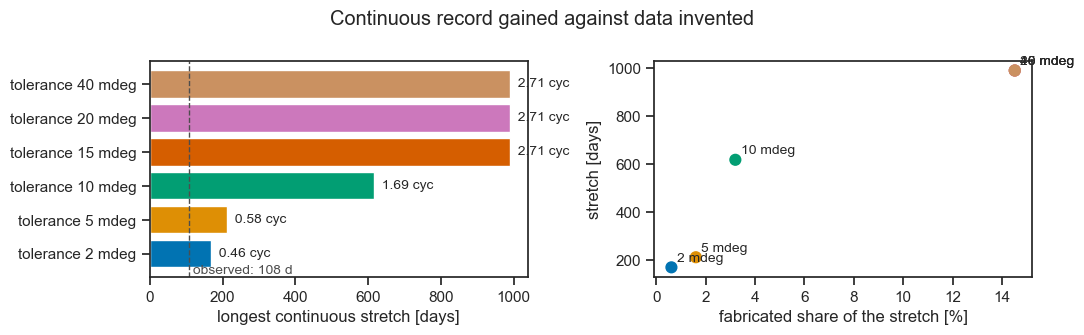

In [21]:
ud.plot_stretch_frontier(
    frontier,
    title='Continuous record gained against data invented',
    save_path=OUTPUT_DIR, filename=f'U_F08_stretch_frontier')
plt.show()

### The same question, refusing the era join

The frontier above lets a stretch cross the instrument changeover, which is
legitimate only because `inc_comp_joined` has had the estimated offset
applied. Refusing that estimate — because the two instruments differ in gain
as well as in zero — confines every stretch to one era.

Note that this is *not* the same as running the frontier on the per-era
column. A run of present values spans the changeover either way; what changes
is whether the values across it mean one thing. The restriction has to be
imposed on the stretch, not inferred from the column.

In [22]:
frontier_era, filled_era = ud.stretch_frontier(
    df, TARGET, policies, drivers=None, dt_hours=SAMPLING_HOURS,
    conformal=conformal, boundary=ud.CURRENT_START)
display(frontier_era[['stretch_days', 'annual_cycles', 'stretch_from',
                      'stretch_to', 'fabricated_%']])
frontier_era.to_csv(f'{OUTPUT_DIR}/U_18_stretch_frontier_within_era.csv')

best_within = frontier_era['stretch_days'].max()
best_across = frontier['stretch_days'].max()
print(f'\nLongest stretch within one era : {best_within:.1f} days '
      f'({best_within / ud.YEAR_DAYS:.2f} annual cycles)')
print(f'Longest stretch across the join: {best_across:.1f} days '
      f'({best_across / ud.YEAR_DAYS:.2f} annual cycles)')
print(f'The join is worth {best_across - best_within:.1f} days.')

,stretch_days,annual_cycles,stretch_from,stretch_to,fabricated_%
policy,,,,,
tolerance 2 mdeg,169.5,0.46,2023-10-30 05:00:00,2024-04-16 17:00:00,0.61
tolerance 5 mdeg,211.5,0.58,2021-08-20 08:00:00,2022-03-19 20:00:00,1.60
tolerance 10 mdeg,617.2,1.69,2020-07-31 17:00:00,2022-04-09 22:00:00,3.20
tolerance 15 mdeg,617.2,1.69,2020-07-31 17:00:00,2022-04-09 22:00:00,3.20
tolerance 20 mdeg,617.2,1.69,2020-07-31 17:00:00,2022-04-09 22:00:00,3.20
tolerance 40 mdeg,617.2,1.69,2020-07-31 17:00:00,2022-04-09 22:00:00,3.20



Longest stretch within one era : 617.2 days (1.69 annual cycles)
Longest stretch across the join: 988.9 days (2.71 annual cycles)
The join is worth 371.7 days.


## Step 7 · The recommended stretch

The policy chosen is the one buying the most continuous record at a
fabricated share the benchmark supports.

In [23]:
best_label = frontier['stretch_days'].idxmax()
best_row = frontier.loc[best_label]
best = filled[best_label]

print(f'Recommended policy : {best_label}')
print(f'Stretch            : {best_row["stretch_from"]} to '
      f'{best_row["stretch_to"]}')
print(f'Length             : {best_row["stretch_days"]:.1f} days '
      f'({best_row["annual_cycles"]:.2f} annual cycles)')
print(f'Fabricated within  : {best_row["fabricated_%"]:.2f} % '
      f'({best_row["filled_in_stretch_h"]:.0f} h)')
print(f'Interval half-width: mean {best_row["mean_half_width"]:.2f} mdeg, '
      f'max {best_row["max_half_width"]:.2f} mdeg '
      f'at {CONFORMAL_LEVEL:.0%} nominal')

stretch = best.loc[best_row['stretch_from']:best_row['stretch_to']]
display(stretch['method'].value_counts().to_frame('hours'))
stretch.to_csv(f'{OUTPUT_DIR}/U_19_recommended_stretch.csv')

Recommended policy : tolerance 15 mdeg
Stretch            : 2023-06-21 14:00:00 to 2026-03-06 11:00:00
Length             : 988.9 days (2.71 annual cycles)
Fabricated within  : 14.52 % (3446 h)
Interval half-width: mean 16.70 mdeg, max 21.44 mdeg at 90% nominal


,hours
method,
observed,20288
kalman,2412
seasonal_naive,653
interpolate,381


### The stretch, drawn with its provenance and its uncertainty

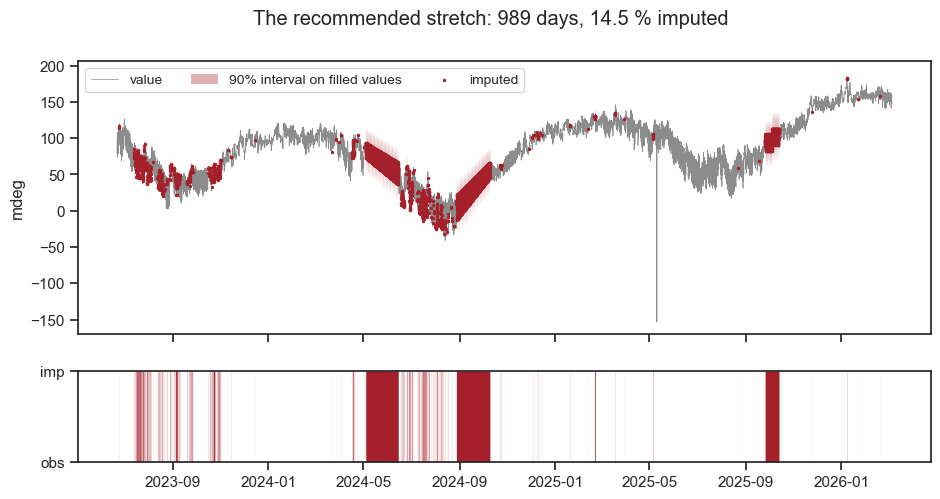

In [24]:
fig, axes = plt.subplots(2, 1, figsize=ud.figsize(11, 5.2), sharex=True,
                         height_ratios=[3, 1])
observed = stretch['source'] == 'observed'
axes[0].plot(stretch.index, stretch['value'], lw=0.5, color='0.55',
             label='value')
axes[0].fill_between(
    stretch.index, stretch['value'] - stretch['half_width'].fillna(0),
    stretch['value'] + stretch['half_width'].fillna(0),
    color='#A5202B', alpha=0.35, lw=0,
    label=f'{CONFORMAL_LEVEL:.0%} interval on filled values')
axes[0].scatter(stretch.index[~observed], stretch['value'][~observed], s=2,
                color='#A5202B', label='imputed', zorder=3)
axes[0].set_ylabel('mdeg')
axes[0].legend(fontsize='small', ncol=3)

axes[1].fill_between(stretch.index, 0, (~observed).astype(int), step='mid',
                     color='#A5202B', lw=0)
axes[1].set_ylim(0, 1)
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['obs', 'imp'])
axes[1].set_xlabel('')

fig.suptitle(f'The recommended stretch: {best_row["stretch_days"]:.0f} days, '
             f'{best_row["fabricated_%"]:.1f} % imputed')
fig.savefig(f'{OUTPUT_DIR}/U_F09_recommended_stretch.png', dpi=150,
            bbox_inches='tight')
plt.show()

## Step 8 · Verdicts

In [25]:
verdict_rows = [
    {'question': 'how many stations, and for how long?',
     'answer': '; '.join(
         f'{s}: {classification.loc[s, "observed_days"]:.0f} observed days, '
         f'last reading {str(classification.loc[s, "last_reading"])[:10]}'
         for s in STATIONS)},
    {'question': 'how complete is the target station?',
     'answer': f'{classification.loc[STATION, "observed_days"]:.0f} of '
               f'{classification.loc[STATION, "span_days"]:.0f} days '
               f'({classification.loc[STATION, "coverage_of_archive_%"]:.1f} %)'},
    {'question': 'where are the missing hours?',
     'answer': f'{len(gaps)} gaps; '
               f'{bands.loc["> 30 d", "share_of_missing_%"]:.1f} % of all '
               f'missing hours sit in the '
               f'{int(bands.loc["> 30 d", "n_gaps"])} gaps over 30 days'},
    {'question': 'what is the missingness mechanism?',
     'answer': 'outage-driven (MNAR): every covariate is missing whenever the '
               'target is, so no covariate-conditioned method can fill a real '
               'gap'},
    {'question': 'best filler, short gaps',
     'answer': '; '.join(
         f'{int(h)} h: '
         f'{bench[bench["gap_hours"] == h].set_index("method")["MAE_mdeg"].idxmin()} '
         f'({bench[bench["gap_hours"] == h]["MAE_mdeg"].min():.2f} mdeg)'
         for h in (1, 6, 24) if (bench['gap_hours'] == h).any())},
    {'question': 'best filler, long gaps',
     'answer': '; '.join(
         f'{int(h)} h: '
         f'{bench[bench["gap_hours"] == h].set_index("method")["MAE_mdeg"].idxmin()} '
         f'({bench[bench["gap_hours"] == h]["MAE_mdeg"].min():.2f} mdeg)'
         for h in (168, 720, 1080) if (bench['gap_hours'] == h).any())},
    {'question': 'the driver filler',
     'answer': 'scores well on injected gaps and is unusable on real ones, '
               'because the drivers fail with the target — the exchangeability '
               'assumption behind the benchmark, failing'},
    {'question': 'longest stretch, nothing filled',
     'answer': f'{frontier.attrs["observed_stretch_days"]:.1f} days '
               f'({frontier.attrs["observed_stretch_from"][:10]} to '
               f'{frontier.attrs["observed_stretch_to"][:10]})'},
    {'question': 'longest stretch, after imputation',
     'answer': f'{best_row["stretch_days"]:.1f} days '
               f'({best_row["annual_cycles"]:.2f} cycles) under {best_label}, '
               f'{best_row["fabricated_%"]:.2f} % of it invented'},
    {'question': 'what still cannot be filled',
     'answer': f'{int((big["hours"] > max(TOLERANCES) * 0 + 1080).sum())} gaps '
               f'exceed the longest benchmarked length; the '
               f'{big["days"].max():.0f}-day outage is unbridgeable at any '
               f'tolerance'},
]
verdicts = pd.DataFrame(verdict_rows).set_index('question')
display(verdicts)
verdicts.to_csv(f'{OUTPUT_DIR}/U_20_verdicts.csv')

,answer
question,
"how many stations, and for how long?","st01: 1119 observed days, last reading 2022-06..."
how complete is the target station?,2061 of 2940 days (70.1 %)
where are the missing hours?,569 gaps; 84.4 % of all missing hours sit in t...
what is the missingness mechanism?,outage-driven (MNAR): every covariate is missi...
"best filler, short gaps",1 h: kalman (1.04 mdeg); 6 h: drivers (2.48 md...
"best filler, long gaps",168 h: drivers (6.98 mdeg); 720 h: seasonal_na...
the driver filler,scores well on injected gaps and is unusable o...
"longest stretch, nothing filled",108.2 days (2025-05-05 to 2025-08-21)
"longest stretch, after imputation",988.9 days (2.71 cycles) under tolerance 15 md...
